In [7]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [4]:
con = duckdb.connect('C:/Users/kweec/python files/risk-project/notebooks/credit_risk.db')

df = con.execute("SELECT * FROM mart.features").df()

# загружаем логит и скейлер
with open('C:/Users/kweec/python files/risk-project/models/model_lr_v2.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('C:/Users/kweec/python files/risk-project/models/scaler_v2.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [19]:
FEATURES = [
    'dti', 'fico_avg', 'annual_inc', 'loan_amnt',
    'installment', 'open_acc', 'revol_util', 'total_acc',
    'loan_to_income', 'payment_to_income',
    'term_months', 'home_ownership', 'purpose'
]

df_bt = df[FEATURES + ['is_default', 'issue_date']].dropna()
df_bt = pd.get_dummies(df_bt, columns=['home_ownership', 'purpose'], drop_first=True)
FEATURES_ENC = [c for c in df_bt.columns if c not in ['is_default', 'issue_date']]

df_bt['pd_pred'] = model_lr.predict_proba(
    scaler.transform(df_bt[FEATURES_ENC]) #что здесь происходит
)[:, 1]

print(f"Строк: {len(df_bt):,}")

Строк: 1,340,262


In [8]:
# разбиваем по году выдачи — проверяем стабильность модели во времени
df_bt['year'] = pd.to_datetime(df_bt['issue_date']).dt.year

results = []
for year in sorted(df_bt['year'].unique()):
    subset = df_bt[df_bt['year'] == year]
    if subset['is_default'].sum() < 100:
        continue
    auc  = roc_auc_score(subset['is_default'], subset['pd_pred'])
    gini = 2 * auc - 1
    ks   = stats.ks_2samp(
        subset[subset['is_default']==1]['pd_pred'],
        subset[subset['is_default']==0]['pd_pred']
    ).statistic
    results.append({'year': year, 'AUC': auc, 'Gini': gini, 'KS': ks,
                    'n': len(subset), 'n_defaults': subset['is_default'].sum()})

df_results = pd.DataFrame(results)
print(df_results.round(3).to_string(index=False))

 year   AUC  Gini    KS      n  n_defaults
 2008 0.573 0.145 0.123   1550         243
 2009 0.616 0.231 0.165   4689         590
 2010 0.666 0.331 0.241  11481        1475
 2011 0.676 0.352 0.262  21694        3291
 2012 0.666 0.332 0.237  53264        8631
 2013 0.678 0.357 0.261 134599       20995
 2014 0.698 0.396 0.290 222718       41111
 2015 0.715 0.429 0.310 374759       75693
 2016 0.695 0.390 0.280 292115       68059
 2017 0.690 0.379 0.275 167729       38763
 2018 0.683 0.366 0.271  55414        8699


In [12]:
def calc_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 1, bins + 1)
    
    exp_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_counts = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    
    # избегаем деления на ноль
    exp_counts = np.where(exp_counts == 0, 0.0001, exp_counts)
    act_counts = np.where(act_counts == 0, 0.0001, act_counts)
    
    psi = np.sum((act_counts - exp_counts) * np.log(act_counts / exp_counts))
    return psi

# базовый период — 2013, сравниваем с каждым годом
base = df_bt[df_bt['year'] == 2013]['pd_pred']

print("PSI по годам (база = 2013):")
print(f"{'Год':<8} {'PSI':<10} {'Статус'}")
print("-" * 30)
for year in sorted(df_bt['year'].unique()):
    if year == 2013:
        continue
    psi = calc_psi(base, df_bt[df_bt['year'] == year]['pd_pred'])
    status = "OK" if psi < 0.1 else ("Внимание" if psi < 0.2 else "Переобучить")
    print(f"{year:<8} {psi:<10.4f} {status}")

PSI по годам (база = 2013):
Год      PSI        Статус
------------------------------
2007     0.7673     Переобучить
2008     0.8806     Переобучить
2009     0.6765     Переобучить
2010     0.1935     Внимание
2011     0.1169     Внимание
2012     0.0223     OK
2014     0.0033     OK
2015     0.0009     OK
2016     0.0092     OK
2017     0.0313     OK
2018     0.0581     OK


In [16]:
def binomial_test(n_obs, n_defaults, pd_predicted_mean):
    result = stats.binomtest(
        n_defaults, n_obs, pd_predicted_mean,
        alternative='two-sided'
    )
    actual_rate = n_defaults / n_obs
    
    return {
        "n_obs":        n_obs,
        "actual_rate":  round(actual_rate, 4),
        "predicted_pd": round(pd_predicted_mean, 4),
        "expected":     round(n_obs * pd_predicted_mean, 1),
        "actual":       n_defaults,
        "p_value":      round(result.pvalue, 4),
        "result":       "OK" if result.pvalue > 0.05 else "FAIL"
    }

print(f"{'Год':<6} {'Наблюд.':<10} {'PD пред.':<10} {'PD факт.':<10} {'p-value':<10} {'Результат'}")
print("-" * 56)

for year in sorted(df_bt['year'].unique()):
    subset = df_bt[df_bt['year'] == year]
    if subset['is_default'].sum() < 100:
        continue
    result = binomial_test(
        n_obs=len(subset),
        n_defaults=subset['is_default'].sum(),
        pd_predicted_mean=subset['pd_pred'].mean()
    )
    print(f"{year:<6} {result['n_obs']:<10,} {result['predicted_pd']:<10.4f} "
          f"{result['actual_rate']:<10.4f} {result['p_value']:<10.4f} {result['result']}")

Год    Наблюд.    PD пред.   PD факт.   p-value    Результат
--------------------------------------------------------
2008   1,550      0.1241     0.1568     0.0002     FAIL
2009   4,689      0.1288     0.1258     0.5562     OK
2010   11,481     0.1584     0.1285     0.0000     FAIL
2011   21,694     0.1711     0.1517     0.0000     FAIL
2012   53,264     0.1838     0.1620     0.0000     FAIL
2013   134,599    0.1993     0.1560     0.0000     FAIL
2014   222,718    0.2053     0.1846     0.0000     FAIL
2015   374,759    0.2009     0.2020     0.1119     OK
2016   292,115    0.2009     0.2330     0.0000     FAIL
2017   167,729    0.2045     0.2311     0.0000     FAIL
2018   55,414     0.1907     0.1570     0.0000     FAIL


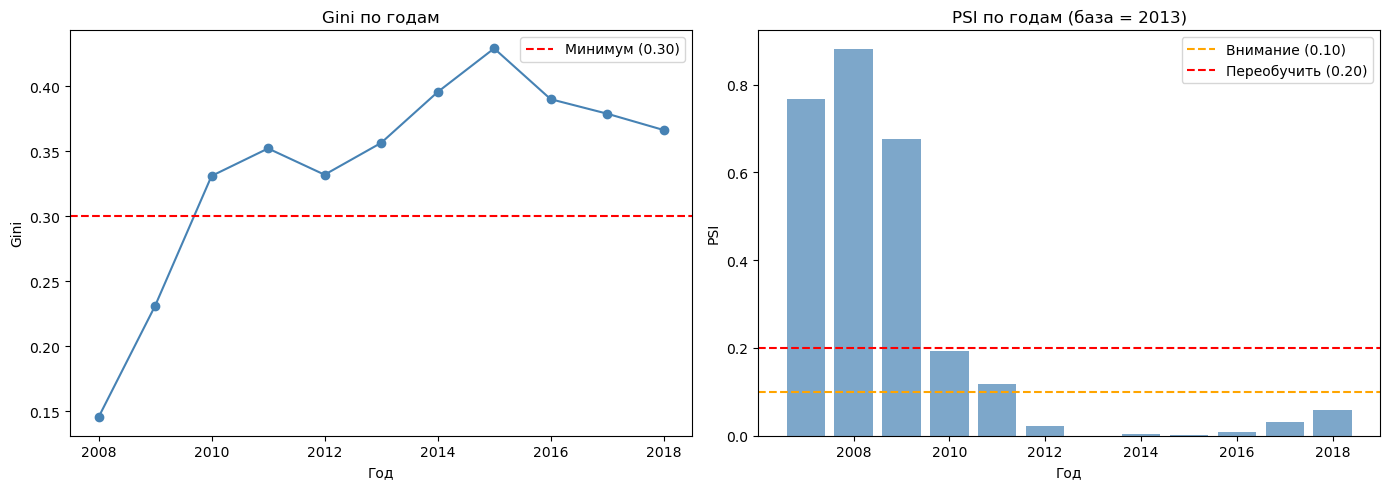

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gini по годам
axes[0].plot(df_results['year'], df_results['Gini'], 'o-', color='steelblue')
axes[0].axhline(0.3, color='red', linestyle='--', label='Минимум (0.30)')
axes[0].set_title('Gini по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Gini')
axes[0].legend()

# PSI по годам
psi_values = []
for year in sorted(df_bt['year'].unique()):
    if year == 2013:
        continue
    psi = calc_psi(base, df_bt[df_bt['year'] == year]['pd_pred'])
    psi_values.append({'year': year, 'PSI': psi})

df_psi = pd.DataFrame(psi_values)
axes[1].bar(df_psi['year'], df_psi['PSI'], color='steelblue', alpha=0.7)
axes[1].axhline(0.1, color='orange', linestyle='--', label='Внимание (0.10)')
axes[1].axhline(0.2, color='red',    linestyle='--', label='Переобучить (0.20)')
axes[1].set_title('PSI по годам (база = 2013)')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('PSI')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
con.close()